#### Construção e limpeza dos dados (Data Preparation Final)

In [5]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Airbnb_NYC_2019.csv")

#### Clustering

In [7]:
df = pd.read_csv("AB_NYC_2019_.csv")

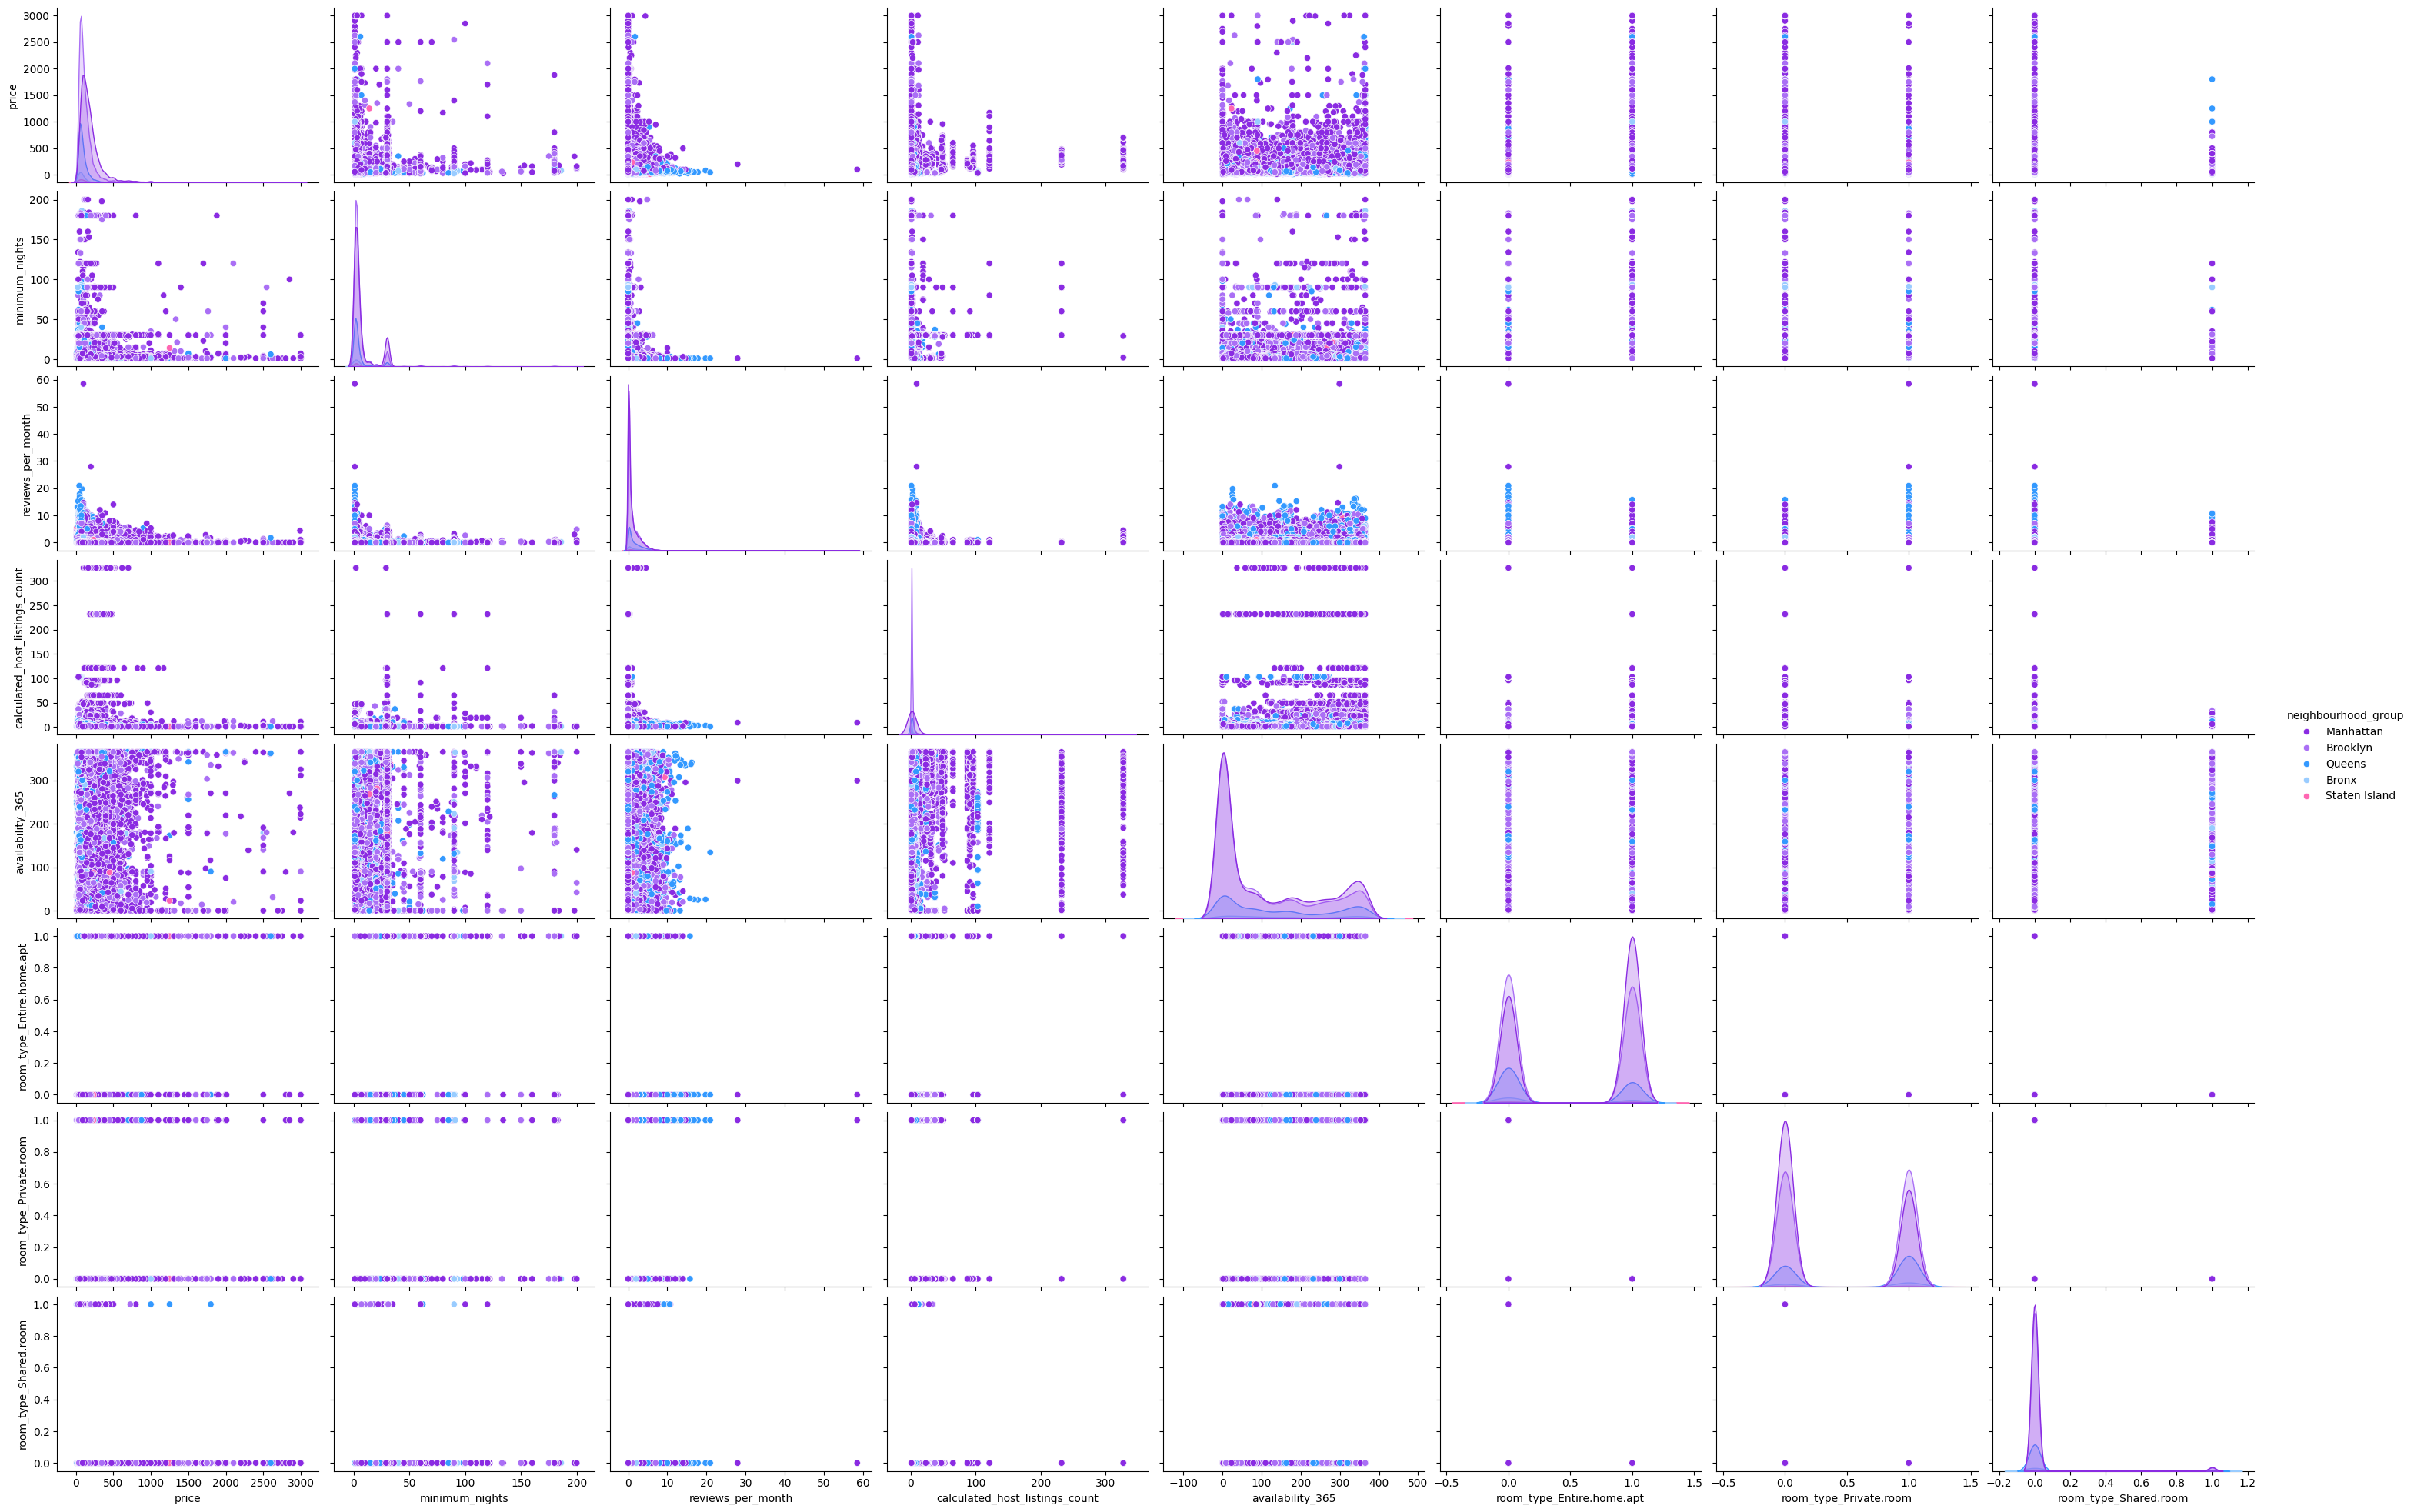

In [8]:
columns = ["price", "minimum_nights", "reviews_per_month", "calculated_host_listings_count", "availability_365", "neighbourhood_group", "room_type_Entire.home.apt", "room_type_Private.room", "room_type_Shared.room"]
palette_custom = {
    0.81412: "#8A2BE2",
    0.88871: "#AA6FF5",
    2.15502: "#3399FF", 
    3.80166: "#99CCFF", 
    4.87317: "#FF66B2"
    }
names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }
g = sns.pairplot(df[columns], hue="neighbourhood_group", aspect=1.5, palette=palette_custom)
for t, l in zip(g._legend.texts, g._legend.texts):
    val = float(t.get_text())
    t.set_text(names_neighbourhood_group.get(val, val))
plt.show()

#### Integração dos Dados - Crimes

In [10]:
import pandas as pd

airbnb = pd.read_csv("AB_NYC_2019_.csv")
crimes = pd.read_csv("crimes.csv")

crimes = crimes[crimes['LAW_DESCRIPTION'].str.upper().str.strip() != '(NULL)']
crimes = crimes[crimes['BORO'] != 'NEW YORK']

grave = ['Penal Law']
medio = ['VTL', 'NYS Workers Comp', 'NYS Transportation', 'Tax Law']
leve = ['Administrative Code', 'ABC', 'ACA', 'Education Law (NYS)', 'Health Code', 'Sanitary Code (NYS)',
        'Park Regs', 'Traffic Regs', 'General Business Law']

def classificar_crime(descricao):
    descricao = descricao.strip()
    if descricao in grave:
        return 'serious_crimes'
    elif descricao in medio:
        return 'moderate_crimes'
    elif descricao in leve:
        return 'minor_crimes'
    else:
        return 'others'  

crimes['gravidade'] = crimes['LAW_DESCRIPTION'].apply(classificar_crime)

crimes_contagem = crimes.groupby(['BORO', 'gravidade']).size().unstack(fill_value=0).reset_index()

for col in ['serious_crimes', 'moderate_crimes', 'minor_crimes']:
    if col not in crimes_contagem.columns:
        crimes_contagem[col] = 0

boro_to_num = {
    'QUEENS': 2.15502,
    'MANHATTAN': 0.81412,
    'BROOKLYN': 0.88871,
    'BRONX': 3.80166,
    'STATEN ISLAND': 4.87317,
}
crimes_contagem['BORO'] = crimes_contagem['BORO'].map(boro_to_num)

airbnb['neighbourhood_group'] = airbnb['neighbourhood_group'].astype(float)
crimes_contagem['BORO'] = crimes_contagem['BORO'].astype(float)

dados_completos = pd.merge(
    airbnb,
    crimes_contagem,
    left_on='neighbourhood_group',
    right_on='BORO',
    how='left'
)

dados_completos = dados_completos.drop(columns=['BORO'])

dados_completos.to_csv("Airbnb_with_crimes.csv", index=False)


In [12]:
df = pd.read_csv("Airbnb_with_crimes.csv")

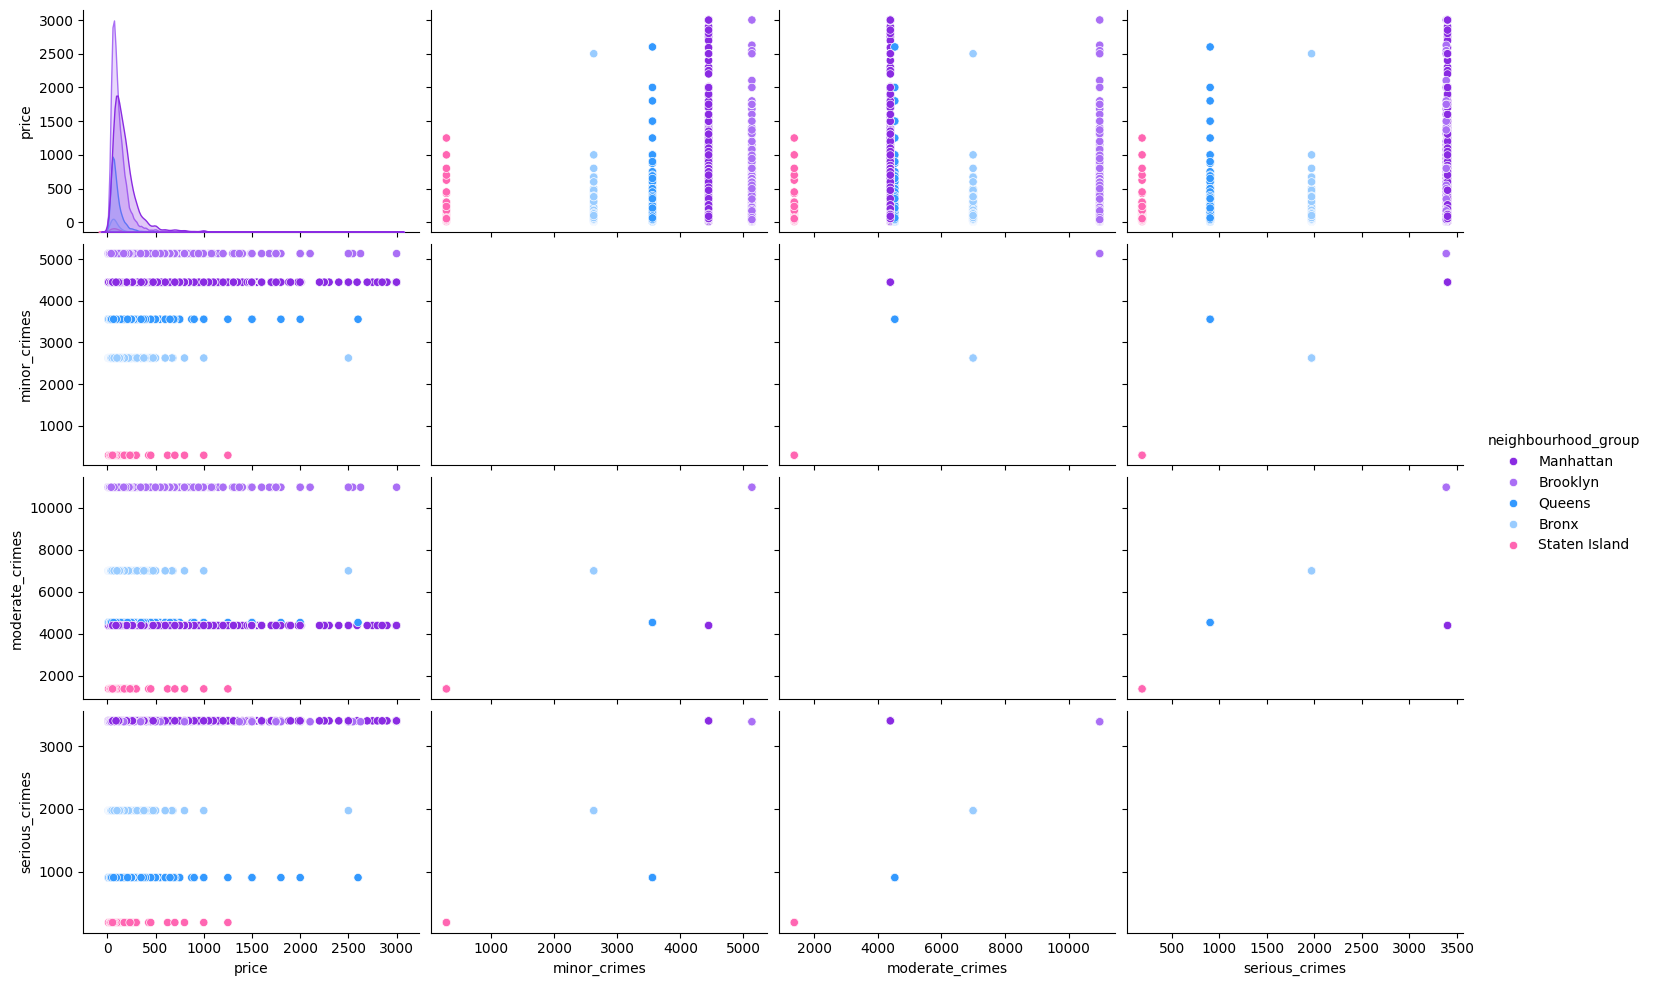

In [13]:
columns = ["price", "neighbourhood_group", "minor_crimes", "moderate_crimes", "serious_crimes"]
palette_custom = {
    0.81412: "#8A2BE2",
    0.88871: "#AA6FF5",
    2.15502: "#3399FF", 
    3.80166: "#99CCFF", 
    4.87317: "#FF66B2"
    }
names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }
g = sns.pairplot(df[columns], hue="neighbourhood_group", aspect=1.5, palette=palette_custom)
for t, l in zip(g._legend.texts, g._legend.texts):
    val = float(t.get_text())
    t.set_text(names_neighbourhood_group.get(val, val))
plt.show()

#### Integração dos Dados - Attractions

In [14]:
from geopy.distance import geodesic
import pandas as pd

airbnb = pd.read_csv('AB_NYC_2019_.csv')

names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }

# lista de atrações turísticas com coordenadas
attractions_by_neighbourhood_group = {
    0.81412: {
        'Times Square': (40.7580, -73.9855),
        'Central Park': (40.7829, -73.9654),
        'Empire State Building': (40.7484, -73.9857),
        'Estátua da Liberdade (vista)': (40.6892, -74.0445),
        'Rockefeller Center': (40.7587, -73.9787),
        'Grand Central Terminal': (40.7527, -73.9772),
        'Museu de História Natural': (40.7813, -73.9735),
        'Museu Metropolitano de Arte': (40.7794, -73.9632),
        'Museu de Arte Moderna (MoMA)': (40.7614, -73.9776),
        'High Line': (40.7479, -74.0049),
        'One World Trade Center': (40.7127, -74.0134),
        '9/11 Memorial & Museum': (40.7115, -74.0134),
    },
    0.88871: {
        'Brooklyn Bridge Park': (40.7003, -73.9967),
        'Brooklyn Museum': (40.6712, -73.9636),
        'Prospect Park': (40.6602, -73.9690),
        'Barclays Center': (40.6827, -73.9757),
        'Coney Island Boardwalk': (40.5749, -73.9850),
        'DUMBO': (40.7033, -73.9881),
    },
    2.15502: {
        'Flushing Meadows Corona Park': (40.7498, -73.8408),
        'Citi Field': (40.7571, -73.8458),
        'Queens Botanical Garden': (40.7516, -73.8276),
        'MoMA PS1': (40.7455, -73.9477),
        'Gantry Plaza State Park': (40.7471, -73.9590),
    },
    3.80166: {
        'Bronx Zoo': (40.8506, -73.8769),
        'New York Botanical Garden': (40.8623, -73.8801),
        'Yankee Stadium': (40.8296, -73.9262),
        'City Island': (40.8465, -73.7860),
    },
    4.87317: {
        'Staten Island Ferry Terminal': (40.6437, -74.0732),
        'Staten Island Greenbelt': (40.5931, -74.1236),
        'Staten Island Zoo': (40.6250, -74.1140),
        'Fort Wadsworth': (40.6054, -74.0571),
    }
}

# guardar os dataframes
updated_dfs = []

# calcular distância para cada atração e adicionar ao dataframe
for neighbourhood_group, attractions in attractions_by_neighbourhood_group.items():
    ng_df = airbnb[airbnb['neighbourhood_group'] == neighbourhood_group].copy()
    attraction_distances = []
    
    for name, coords in attractions.items():
        col_name = name + '_dist_km'
        ng_df[col_name] = ng_df.apply(
            lambda row: geodesic((row['latitude'], row['longitude']), coords).kilometers,
            axis=1
        )
        attraction_distances.append(col_name)
    
    # distância de cada airbnb às atrações
    dist_columns = [col for col in ng_df.columns if '_dist_km' in col]
    ng_df[dist_columns] = ng_df[dist_columns].round(3)
    
    # contar quantas atrações estão a <= 2 km
    ng_df['attractions'] = ng_df[attraction_distances].le(2).sum(axis=1)
    
    # salvar a coluna com a distância mínima
    ng_df = ng_df.drop(columns=['host_id', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'calculated_host_listings_count'])
    neighbourhood_name = names_neighbourhood_group[neighbourhood_group]
    updated_dfs.append(ng_df[['id', 'attractions']])

# unir os dataframes com distância mínima
attractions_df = pd.concat(updated_dfs)
airbnb = airbnb.merge(attractions_df, on='id', how='left')
airbnb.to_csv('Airbnb_with_attractions.csv', index=False)

In [15]:
df = pd.read_csv("Airbnb_with_attractions.csv")

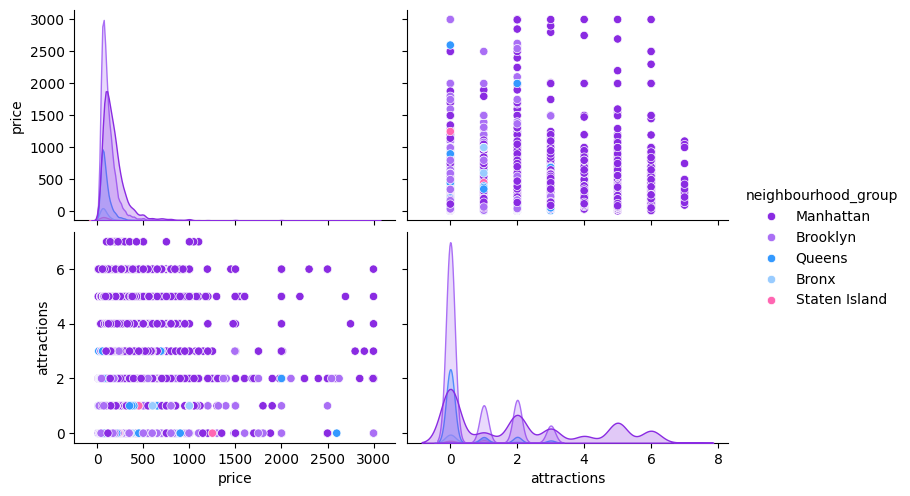

In [16]:
columns = ["price", "neighbourhood_group", "attractions"]
palette_custom = {
    0.81412: "#8A2BE2",
    0.88871: "#AA6FF5",
    2.15502: "#3399FF", 
    3.80166: "#99CCFF", 
    4.87317: "#FF66B2"
    }
names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }
g = sns.pairplot(df[columns], hue="neighbourhood_group", aspect=1.5, palette=palette_custom)
for t, l in zip(g._legend.texts, g._legend.texts):
    val = float(t.get_text())
    t.set_text(names_neighbourhood_group.get(val, val))
plt.show()

#### Versão Final dataset com crimes e attractions

In [17]:
import pandas as pd

airbnb_crimes = pd.read_csv("Airbnb_with_crimes.csv")
airbnb_attractions = pd.read_csv("Airbnb_with_attractions.csv")

final_df = pd.merge(
    airbnb_crimes,
    airbnb_attractions[['id', 'attractions']], 
    on='id',
    how='inner'  
)

final_df.to_csv("Airbnb_NYC_2019_VF.csv", index=False)

In [18]:
df = pd.read_csv("Airbnb_NYC_2019_VF.csv")

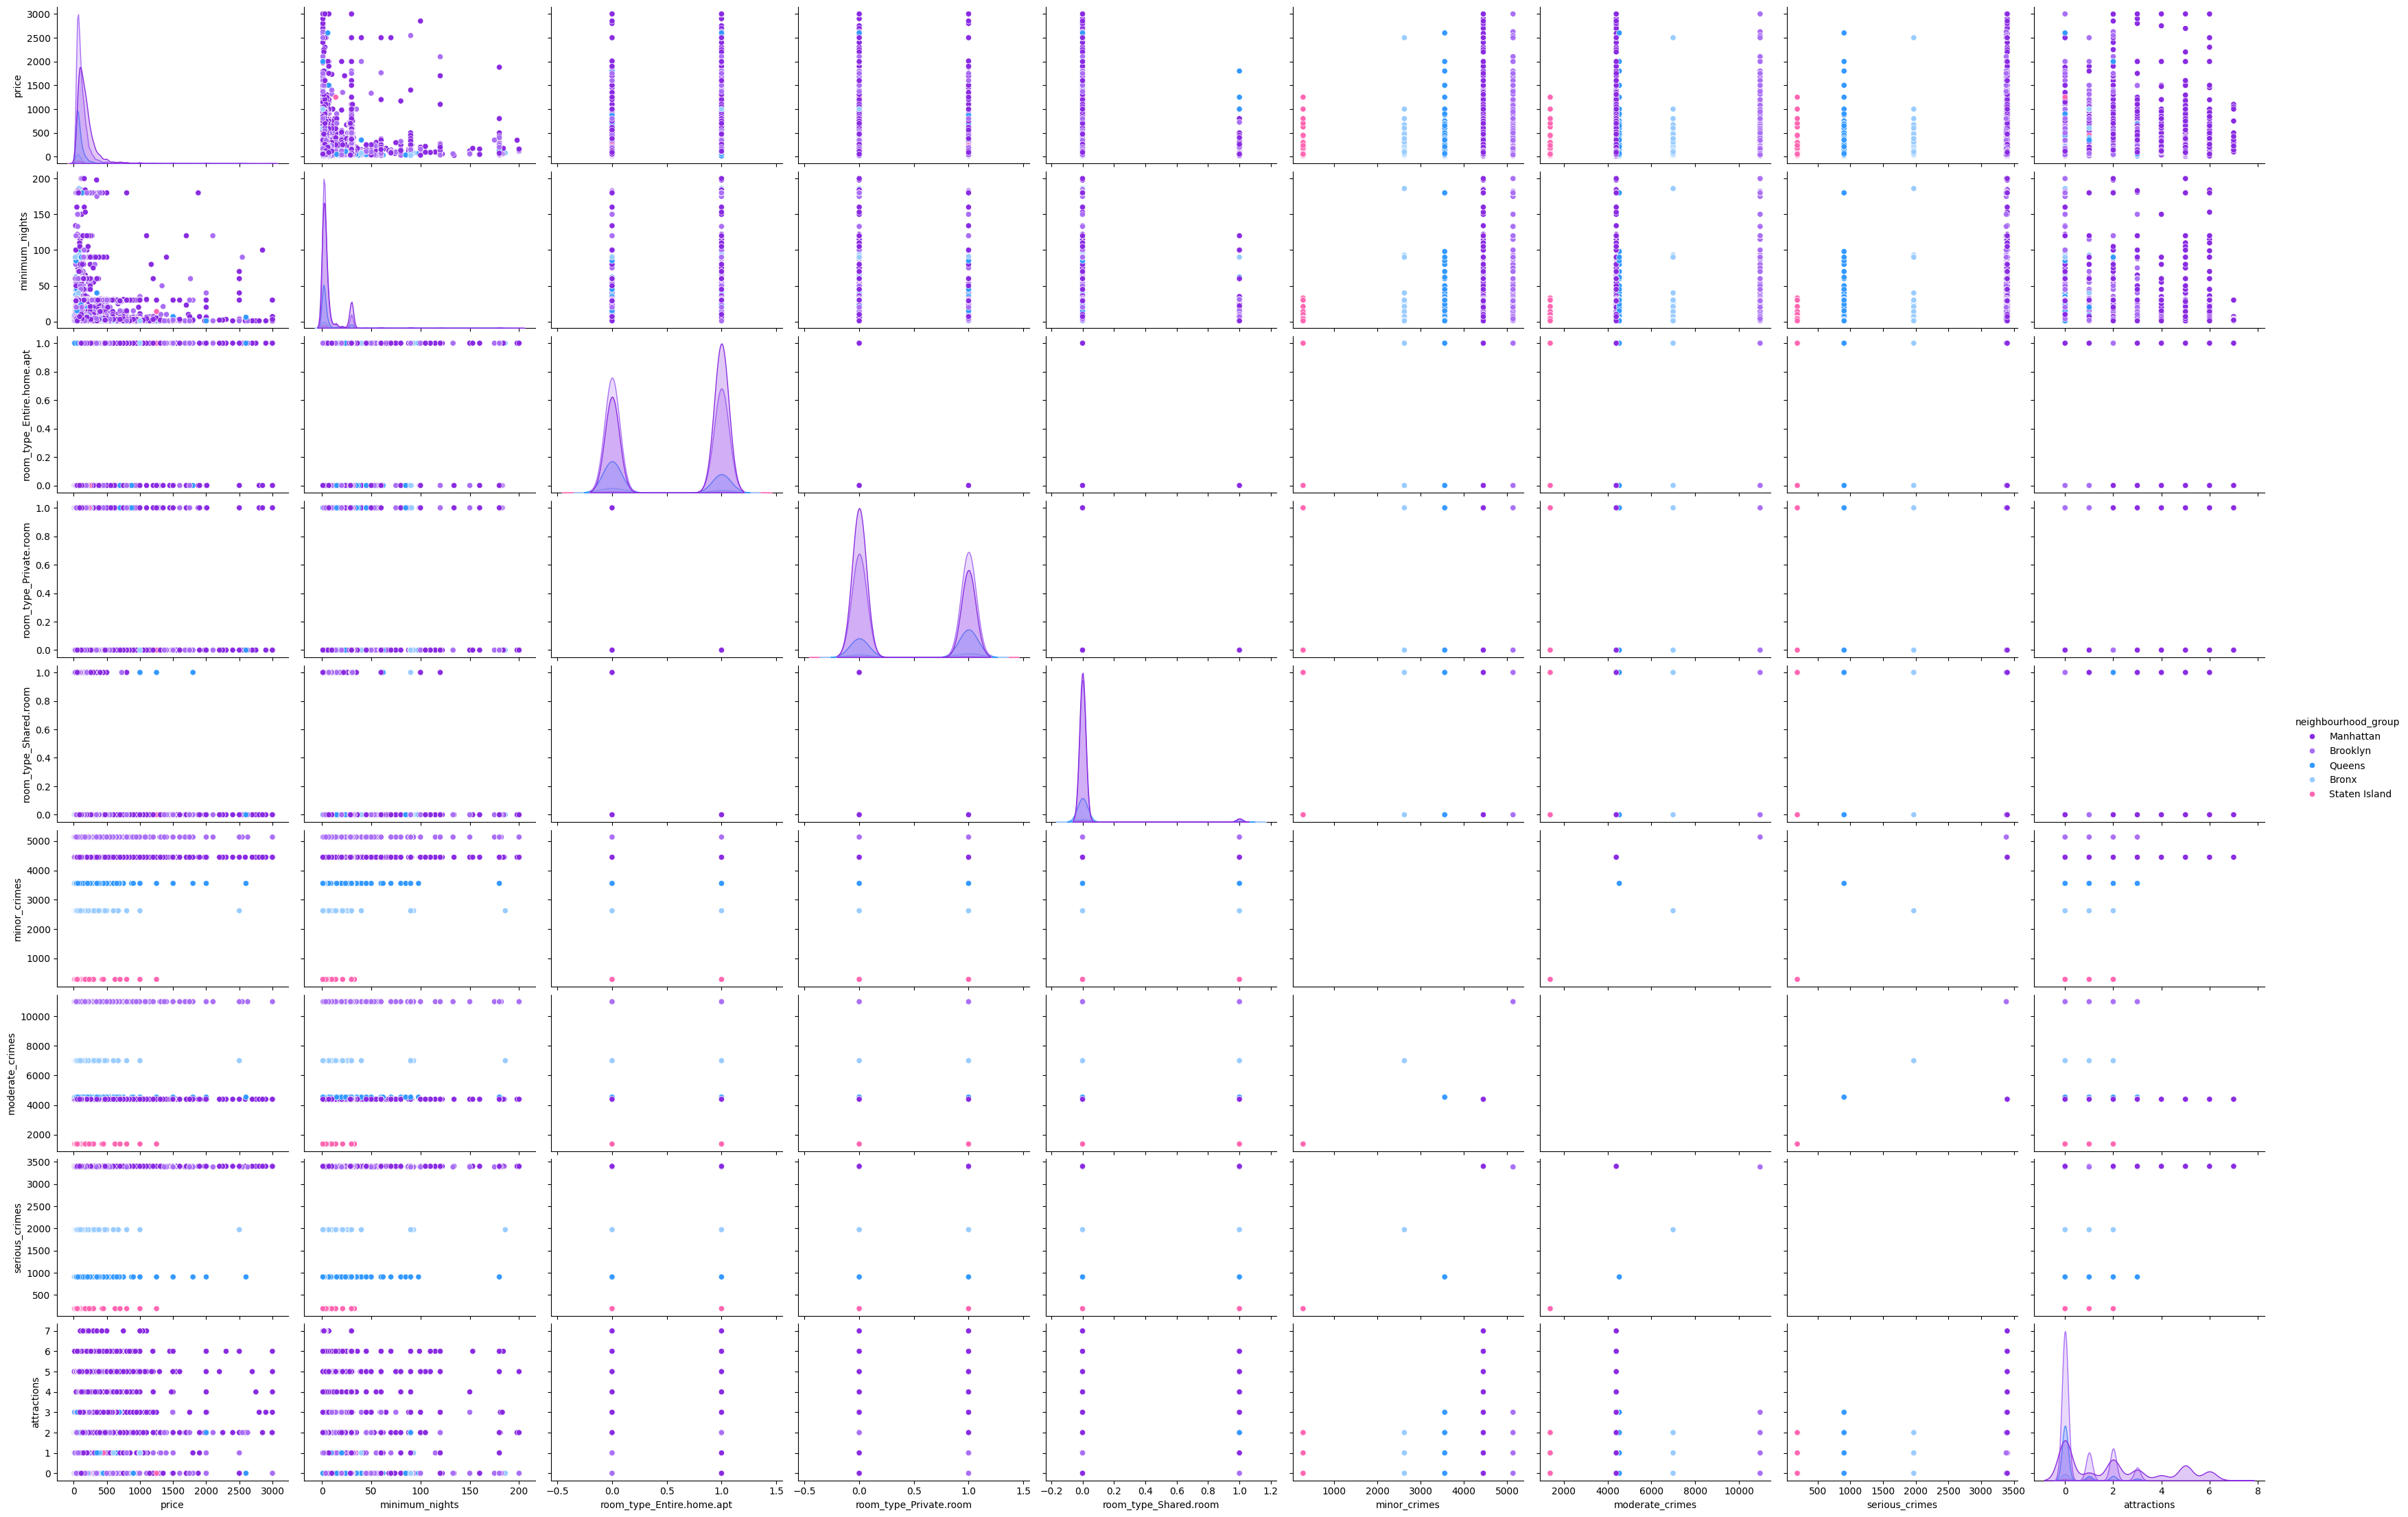

In [19]:
columns = ["price", "minimum_nights", "neighbourhood_group", "room_type_Entire.home.apt", "room_type_Private.room", "room_type_Shared.room", "minor_crimes", "moderate_crimes", "serious_crimes", "attractions"]
palette_custom = {
    0.81412: "#8A2BE2",
    0.88871: "#AA6FF5",
    2.15502: "#3399FF", 
    3.80166: "#99CCFF", 
    4.87317: "#FF66B2"
    }
names_neighbourhood_group = {
    0.81412: "Manhattan",
    0.88871: "Brooklyn",
    2.15502: "Queens",
    3.80166: "Bronx",
    4.87317: "Staten Island"
    }
g = sns.pairplot(df[columns], hue="neighbourhood_group", aspect=1.5, palette=palette_custom)
for t, l in zip(g._legend.texts, g._legend.texts):
    val = float(t.get_text())
    t.set_text(names_neighbourhood_group.get(val, val))
plt.show()